<a href="https://colab.research.google.com/github/malakeha/GIU-Nexus/blob/main/Copy_of_MJN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the training data
train_df = pd.read_csv('train.csv')

# ===== Step 1(b): Internal Splitting =====

target_col = "MetabolicSyndrome"

X = train_df.drop(columns=[target_col])
y = train_df[target_col]

In [ ]:
#Step 1(c): Train-Validation Split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# ===== Step 1(a): Preprocessing =====

id_col = "seqn"

# Load the test data
test_df = pd.read_csv('test.csv')

# Remove ID column
X_train = X_train.drop(columns=[id_col], errors='ignore')
X_val = X_val.drop(columns=[id_col], errors='ignore')
X_test = test_df.drop(columns=[id_col], errors='ignore')

# Categorical encoding
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align columns
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Handle missing values
X_train = X_train.fillna(X_train.median())
X_val = X_val.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Feature scaling for kNN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ===== Step 2: Hyperparameter Tuning (kNN) =====

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

results_knn = []

for k in [3, 5, 7, 9, 11]:
    for metric in ['euclidean', 'manhattan']:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)
        pred = knn.predict(X_val_scaled)
        acc = accuracy_score(y_val, pred)

        results_knn.append((k, metric, acc))
        print(f"k={k}, metric={metric}, Accuracy={acc:.4f}")

best_knn = max(results_knn, key=lambda x: x[2])
print("\nBest kNN:", best_knn)

knn_final = KNeighborsClassifier(
    n_neighbors=best_knn[0],
    metric=best_knn[1]
)
knn_final.fit(X_train_scaled, y_train)

k=3, metric=euclidean, Accuracy=0.7656
k=3, metric=manhattan, Accuracy=0.7630
k=5, metric=euclidean, Accuracy=0.7760
k=5, metric=manhattan, Accuracy=0.7656
k=7, metric=euclidean, Accuracy=0.7760
k=7, metric=manhattan, Accuracy=0.7734
k=9, metric=euclidean, Accuracy=0.7578
k=9, metric=manhattan, Accuracy=0.7578
k=11, metric=euclidean, Accuracy=0.7734
k=11, metric=manhattan, Accuracy=0.7656

Best kNN: (5, 'euclidean', 0.7760416666666666)


KNeighborsClassifier(metric='euclidean')

In [ ]:
# ===== Step 2: Hyperparameter Tuning (Naive Bayes) =====

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

results_nb = []

for v in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]:
    nb = GaussianNB(var_smoothing=v)
    nb.fit(X_train_scaled, y_train)
    pred = nb.predict(X_val_scaled)
    acc = accuracy_score(y_val, pred)

    results_nb.append((v, acc))
    print(f"var_smoothing={v}, Accuracy={acc:.4f}")

best_nb = max(results_nb, key=lambda x: x[1])
print("\nBest NB:", best_nb)

nb_final = GaussianNB(var_smoothing=best_nb[0])
nb_final.fit(X_train_scaled, y_train)

var_smoothing=1e-09, Accuracy=0.7682
var_smoothing=1e-08, Accuracy=0.7682
var_smoothing=1e-07, Accuracy=0.7682
var_smoothing=1e-06, Accuracy=0.7682
var_smoothing=1e-05, Accuracy=0.7682

Best NB: (1e-09, 0.7682291666666666)


GaussianNB()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = knn_final.predict(X_val_scaled)

cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[225  28]
 [ 58  73]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions already done
y_pred = knn_final.predict(X_val_scaled)

# Confusion matrix values
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# Specificity (manual)
specificity = tn / (tn + fp)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity:", specificity)
print("F1-score:", f1)

Accuracy: 0.7760416666666666
Precision: 0.7227722772277227
Recall: 0.5572519083969466
Specificity: 0.8893280632411067
F1-score: 0.6293103448275862


AUC: 0.8172615635277434


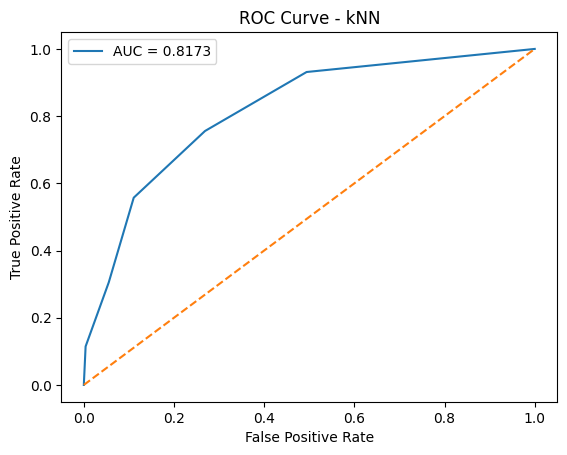

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities for class 1
y_proba = knn_final.predict_proba(X_val_scaled)[:, 1]

# AUC
auc = roc_auc_score(y_val, y_proba)
print("AUC:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - kNN")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Predict on the test set using the final kNN model
test_predictions = best_knn_grid.predict_proba(X_test_scaled)[:, 1] # Use predict_proba for ROC-AUC scoring

# Create a submission DataFrame
# Use 'id' column directly from test_df as required by the submission platform
# The target column is 'MetabolicSyndrome' based on the problem definition
submission_df = pd.DataFrame({'id': test_df['id'], 'MetabolicSyndrome': test_predictions})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)

# Download the file
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score # Import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for kNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize GridSearchCV for kNN
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='roc_auc', # Change scoring to roc_auc
    cv=5, # Use 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_knn.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best kNN parameters:", grid_search_knn.best_params_)
print("Best kNN ROC-AUC on validation set (from CV):", grid_search_knn.best_score_) # Update print statement

# Get the best kNN estimator
best_knn_grid = grid_search_knn.best_estimator_

# Evaluate the best kNN model on the validation set
knn_grid_pred = best_knn_grid.predict(X_val_scaled)
knn_grid_pred_proba = best_knn_grid.predict_proba(X_val_scaled)[:, 1] # Get probabilities for ROC-AUC
knn_grid_acc = accuracy_score(y_val, knn_grid_pred)
knn_grid_auc = roc_auc_score(y_val, knn_grid_pred_proba) # Calculate AUC
print(f"kNN (GridSearch) accuracy on the hold-out validation set: {knn_grid_acc:.4f}")
print(f"kNN (GridSearch) ROC-AUC on the hold-out validation set: {knn_grid_auc:.4f}") # Print AUC

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best kNN parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}
Best kNN ROC-AUC on validation set (from CV): 0.8866309946358518
kNN (GridSearch) accuracy on the hold-out validation set: 0.7812
kNN (GridSearch) ROC-AUC on the hold-out validation set: 0.8818


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score # Import roc_auc_score

# Define the parameter grid for Gaussian Naive Bayes
# var_smoothing is the only hyperparameter that can be tuned
b_param_grid = {
    'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Initialize GridSearchCV for Naive Bayes
grid_search_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=nb_param_grid,
    scoring='roc_auc', # Change scoring to roc_auc
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_nb.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best Naive Bayes parameters:", grid_search_nb.best_params_)
print("Best Naive Bayes ROC-AUC on validation set (from CV):", grid_search_nb.best_score_) # Update print statement

# Get the best Naive Bayes estimator
best_nb_grid = grid_search_nb.best_estimator_

# Evaluate the best Naive Bayes model on the validation set
nb_grid_pred = best_nb_grid.predict(X_val_scaled)
nb_grid_pred_proba = best_nb_grid.predict_proba(X_val_scaled)[:, 1] # Get probabilities for ROC-AUC
nb_grid_acc = accuracy_score(y_val, nb_grid_pred)
nb_grid_auc = roc_auc_score(y_val, nb_grid_pred_proba) # Calculate AUC
print(f"Naive Bayes (GridSearch) accuracy on the hold-out validation set: {nb_grid_acc:.4f}")
print(f"Naive Bayes (GridSearch) ROC-AUC on the hold-out validation set: {nb_grid_auc:.4f}") # Print AUC

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Naive Bayes parameters: {'var_smoothing': 0.1}
Best Naive Bayes ROC-AUC on validation set (from CV): 0.8580645476946616
Naive Bayes (GridSearch) accuracy on the hold-out validation set: 0.7760
Naive Bayes (GridSearch) ROC-AUC on the hold-out validation set: 0.8683


In [ ]:
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
logreg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], # Inverse of regularization strength
    'penalty': ['l1', 'l2'], # Regularization type
    'solver': ['liblinear', 'saga'] # Solvers that support l1 and l2
}

# Initialize GridSearchCV for Logistic Regression
grid_search_logreg = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42), # Increase max_iter for convergence
    param_grid=logreg_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_logreg.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best Logistic Regression parameters:", grid_search_logreg.best_params_)
print("Best Logistic Regression accuracy on validation set (from CV):", grid_search_logreg.best_score_)

# Get the best Logistic Regression estimator
best_logreg_grid = grid_search_logreg.best_estimator_

# Evaluate the best Logistic Regression model on the validation set
logreg_grid_pred = best_logreg_grid.predict(X_val_scaled)
logreg_grid_acc = accuracy_score(y_val, logreg_grid_pred)
print(f"Logistic Regression (GridSearch) accuracy on the hold-out validation set: {logreg_grid_acc:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Logistic Regression parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Logistic Regression accuracy on validation set (from CV): 0.8372498836668217
Logistic Regression (GridSearch) accuracy on the hold-out validation set: 0.8516


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
# This can be computationally intensive, so we'll start with a reasonable range
rf_param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20], # Maximum depth of the tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2], # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), # Fix random state for reproducibility
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation to reduce computation time, can be increased later
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_rf.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best Random Forest parameters:", grid_search_rf.best_params_)
print("Best Random Forest accuracy on validation set (from CV):", grid_search_rf.best_score_)

# Get the best Random Forest estimator
best_rf_grid = grid_search_rf.best_estimator_

# Evaluate the best Random Forest model on the validation set
rf_grid_pred = best_rf_grid.predict(X_val_scaled)
rf_grid_acc = accuracy_score(y_val, rf_grid_pred)
print(f"Random Forest (GridSearch) accuracy on the hold-out validation set: {rf_grid_acc:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Random Forest parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest accuracy on validation set (from CV): 0.88671875
Random Forest (GridSearch) accuracy on the hold-out validation set: 0.8776


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for Gradient Boosting
# This can be computationally intensive, so we'll start with a reasonable range
gbc_param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Step size shrinkage
    'max_depth': [3, 5, 7], # Maximum depth of the individual regression estimators
    'subsample': [0.7, 0.9, 1.0] # Fraction of samples to be used for fitting the individual base learners
}

# Initialize GridSearchCV for Gradient Boosting
grid_search_gbc = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42), # Fix random state for reproducibility
    param_grid=gbc_param_grid,
    scoring='accuracy',
    cv=3, # Using 3-fold cross-validation to reduce computation time
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the scaled training data
grid_search_gbc.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best Gradient Boosting parameters:", grid_search_gbc.best_params_)
print("Best Gradient Boosting accuracy on validation set (from CV):", grid_search_gbc.best_score_)

# Get the best Gradient Boosting estimator
best_gbc_grid = grid_search_gbc.best_estimator_

# Evaluate the best Gradient Boosting model on the validation set
gbc_grid_pred = best_gbc_grid.predict(X_val_scaled)
gbc_grid_acc = accuracy_score(y_val, gbc_grid_pred)
print(f"Gradient Boosting (GridSearch) accuracy on the hold-out validation set: {gbc_grid_acc:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9}
Best Gradient Boosting accuracy on validation set (from CV): 0.8854166666666666
Gradient Boosting (GridSearch) accuracy on the hold-out validation set: 0.9036
